# Libraries

In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import pylab as plt
import scipy.stats

from IPython.display import display

from subprocess import check_output
print(check_output(["ls", "../input"]).decode("utf8"))

sample_submission.csv
test.csv
train.csv



# Explore the Data

In [2]:
# Read the .csv file
house_train = pd.read_csv("../input/train.csv")
house_train.head().T[:30]

,0,1,2,3,4
Id,1,2,3,4,5
MSSubClass,60,20,60,70,60
MSZoning,RL,RL,RL,RL,RL
LotFrontage,65,80,68,60,84
LotArea,8450,9600,11250,9550,14260
Street,Pave,Pave,Pave,Pave,Pave
Alley,NaN,NaN,NaN,NaN,NaN
LotShape,Reg,Reg,IR1,IR1,IR1
LandContour,Lvl,Lvl,Lvl,Lvl,Lvl
Utilities,AllPub,AllPub,AllPub,AllPub,AllPub


In [3]:
house_train['HeatingQC'].dtype

dtype('O')

In [4]:
set(house_train['HeatingQC'].values)

{'Ex', 'Fa', 'Gd', 'Po', 'TA'}

In [5]:
house_train['HeatingQC'].isnull().sum()

0

In [6]:
house_train['BldgType'].dtype

dtype('O')

In [7]:
set(house_train['BldgType'].values)

{'1Fam', '2fmCon', 'Duplex', 'Twnhs', 'TwnhsE'}

In [8]:
house_train['BldgType'].isnull().sum()

0

# Chi-Square Tests

In [9]:
# Create a random sample
sample = house_train.sample(300)

In [10]:
# By default the null hypothesis for one variable is 
# "the categories are assumed to be equally likely".

In [11]:
# A chi-square test for BldgType
scipy.stats.chisquare(pd.factorize(sample['BldgType'])[0])

Power_divergenceResult(statistic=130.74576271186442, pvalue=1.0)

In [12]:
# pvalue < 0.05, reject the null hypothesis

In [13]:
# A chi-square test for RoofStyle
scipy.stats. chisquare(pd.factorize(sample['HeatingQC'])[0])

Power_divergenceResult(statistic=206.1269841269841, pvalue=0.99998952492744964)

In [14]:
# pvalue > 0.05, accept the null hypothesis

In [15]:
# The null hypothesis for two variables is 
# "the variable HeatingQC and the variable BldgType are independent".

In [16]:
# Build the crosstable sums (contingency table) of each category-relationship
cross_table = pd.crosstab(sample['HeatingQC'], sample['BldgType'])
cross_table

BldgType,1Fam,2fmCon,Duplex,Twnhs,TwnhsE
HeatingQC,,,,,
Ex,123,1,3,6,19
Fa,8,0,1,0,0
Gd,41,2,1,1,2
TA,65,4,13,3,7


In [17]:
# A chi-square test for independence of variables in a contingency table
chi2, p, dof, ex = scipy.stats.chi2_contingency(cross_table)
chi2, p, dof

(26.332493238228995, 0.009628853110548001, 12)

In [18]:
# We can't belive in the test results, because there are lots of small values (<5)
# in the contingency table

# PLots

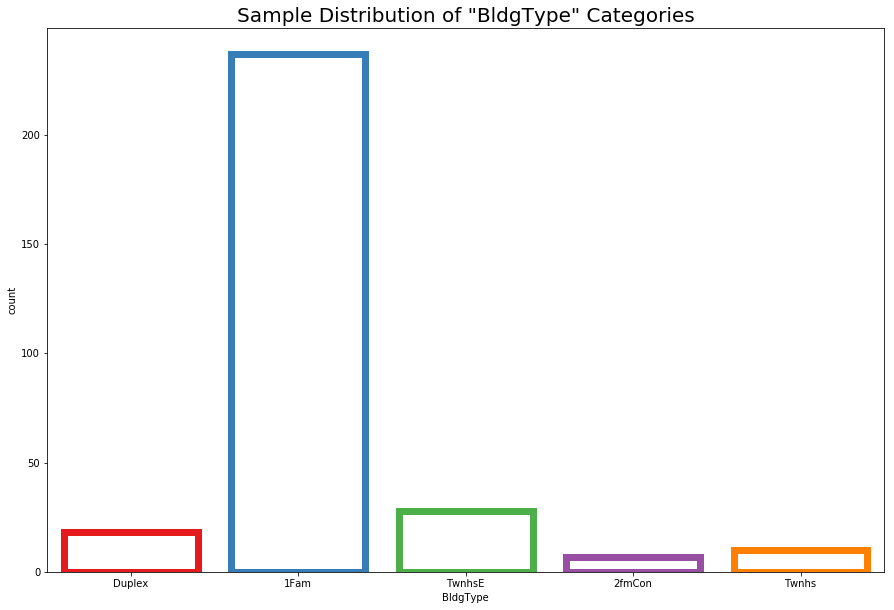

In [19]:
plt.figure(figsize=(15,10))
sns.countplot(x="BldgType", data=sample,
              facecolor=(0, 0, 0, 0), linewidth=7,
              edgecolor=sns.color_palette("Set1", 7))
plt.title('Sample Distribution of "BldgType" Categories', fontsize=20);

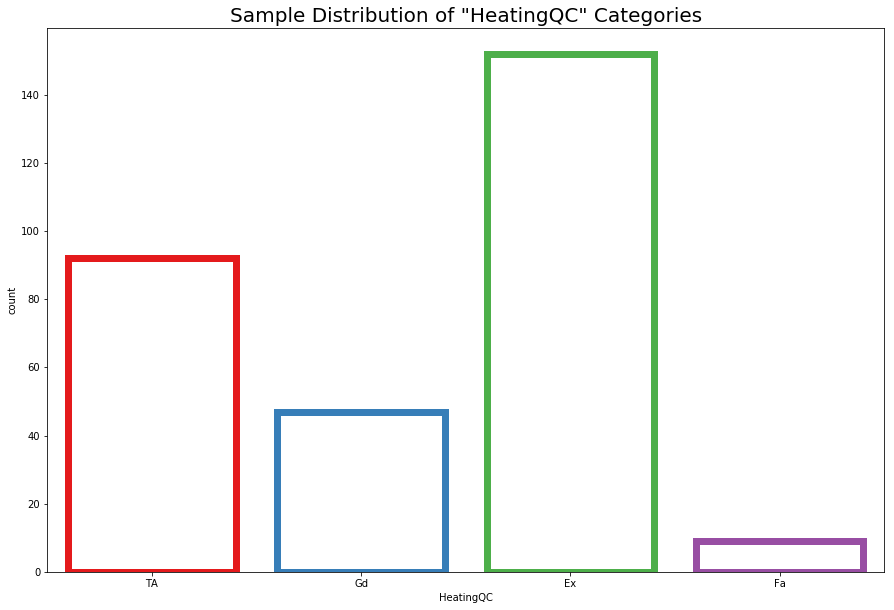

In [20]:
plt.figure(figsize=(15,10))
sns.countplot(x="HeatingQC", data=sample,
              facecolor=(0, 0, 0, 0), linewidth=7,
              edgecolor=sns.color_palette("Set1", 7))
plt.title('Sample Distribution of "HeatingQC" Categories', fontsize=20);

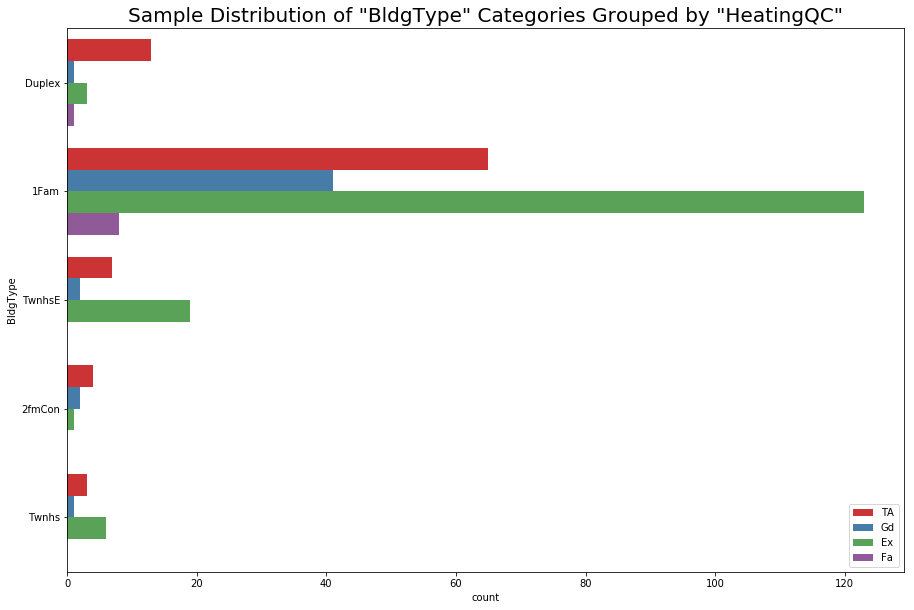

In [21]:
plt.figure(figsize=(15,10))
sns.countplot(y="BldgType", hue="HeatingQC", data=sample, palette='Set1')
plt.legend(loc=4)
plt.title('Sample Distribution of "BldgType" Categories Grouped by "HeatingQC"', 
          fontsize=20);